In [38]:
from sklearn.datasets import load_wine
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

data = load_wine()

df = pd.DataFrame(data.data, columns=data.feature_names)

subset = df[["alcohol", "magnesium"]]

df["target"] = data.target
y = data.target 

Understand the data

In [42]:
print(df.shape)
print(df.columns)

#target distribution
df['target'].value_counts()

#Human-readable  class labels
df['class'] = df['target'].map(dict(enumerate(data.target_names)))

print(df)



(178, 15)
Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline', 'target', 'class'],
      dtype='object')
     alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0      14.23        1.71  2.43               15.6      127.0           2.80   
1      13.20        1.78  2.14               11.2      100.0           2.65   
2      13.16        2.36  2.67               18.6      101.0           2.80   
3      14.37        1.95  2.50               16.8      113.0           3.85   
4      13.24        2.59  2.87               21.0      118.0           2.80   
..       ...         ...   ...                ...        ...            ...   
173    13.71        5.65  2.45               20.5       95.0           1.68   
174    13.40        3.91  2.48               23.0      102.0           1.80   


Basic data quality checks

In [40]:
print("missing values ",df.isnull().sum())
print("duplicates ",df.duplicated().sum())

missing values  alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
class                           0
dtype: int64
duplicates  0


Exploratory Data Analysis

In [19]:
df.describe()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


Features distribution

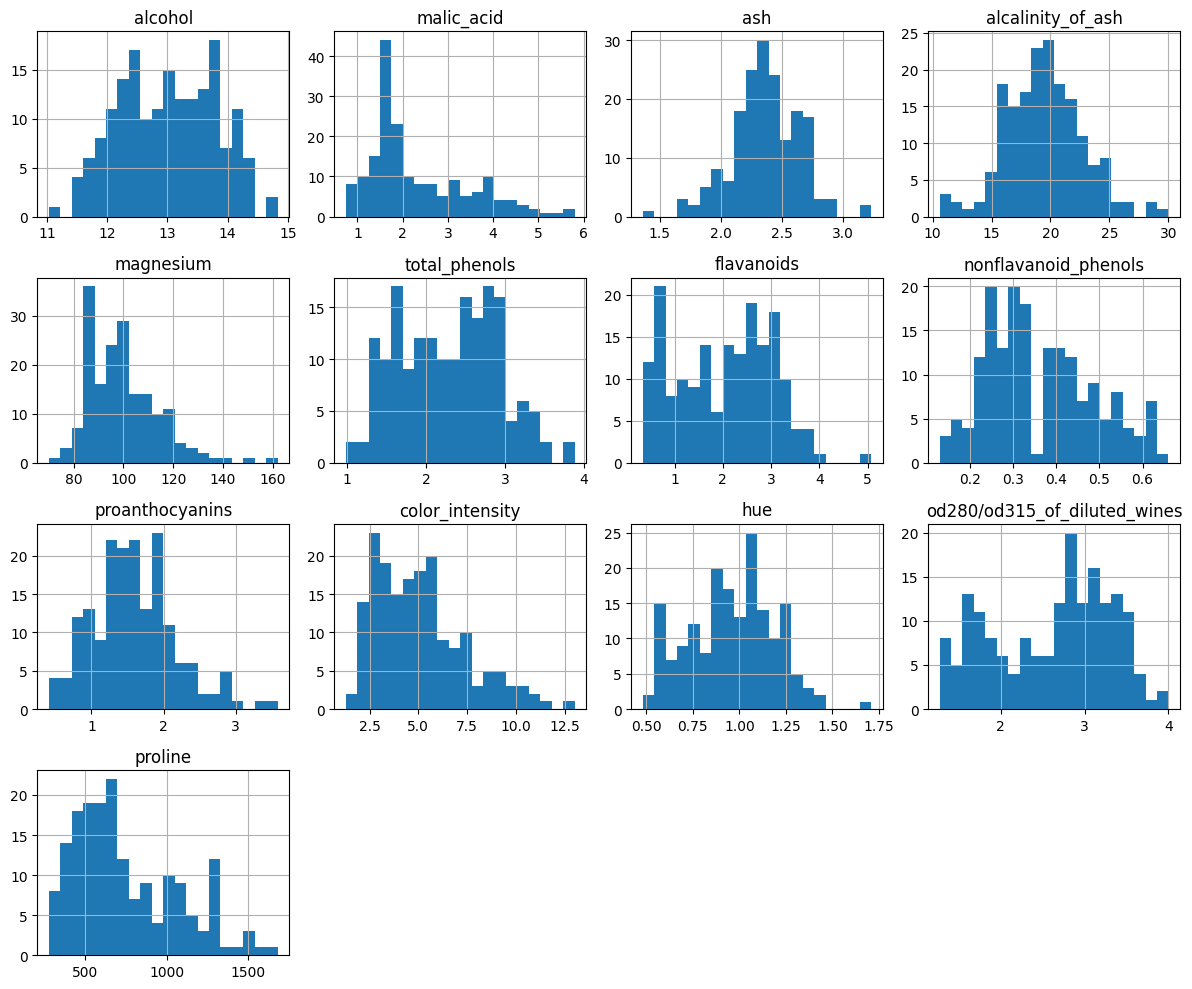

In [ ]:
import matplotlib.pyplot as plt

df.drop(columns=['target', 'class']).hist(figsize=(12, 10),bins=20)
plt.tight_layout()
plt.show()


Correlation matrix

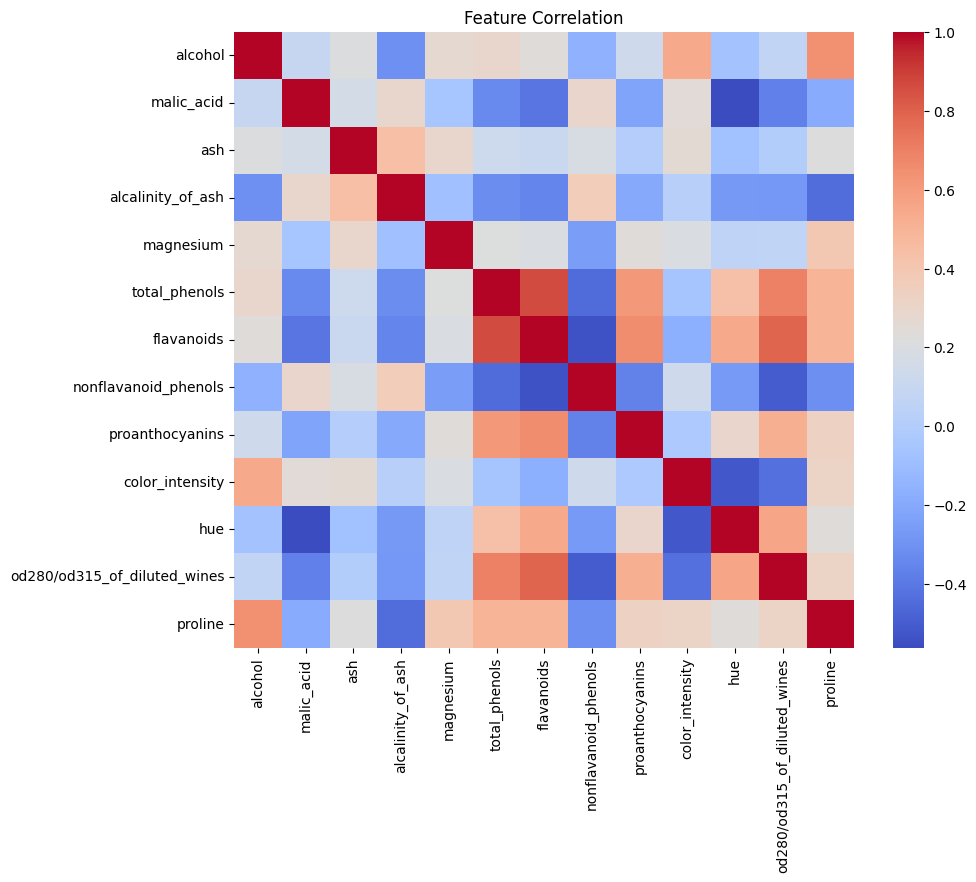

In [43]:
import seaborn as sns

corr = df.drop(columns=['target', 'class']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()


Split between train and test sets

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    subset, y, test_size=0.3, random_state=42
)

model = LogisticRegression(max_iter = 500)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(y_pred)


[0 0 2 0 1 0 1 0 1 2 2 0 2 1 0 1 1 1 0 1 0 2 1 0 1 0 1 1 1 0 0 1 2 0 0 0 0
 1 1 2 2 1 1 0 2 2 1 1 1 0 2 0 2 2]


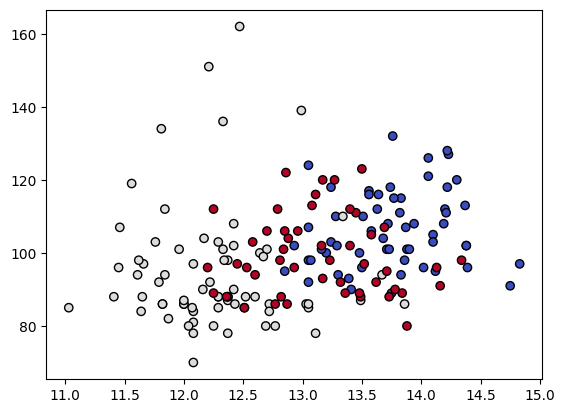

In [ ]:
scatter = plt.scatter(df["alcohol"], df["magnesium"], c=y, cmap='coolwarm', edgecolors='k')


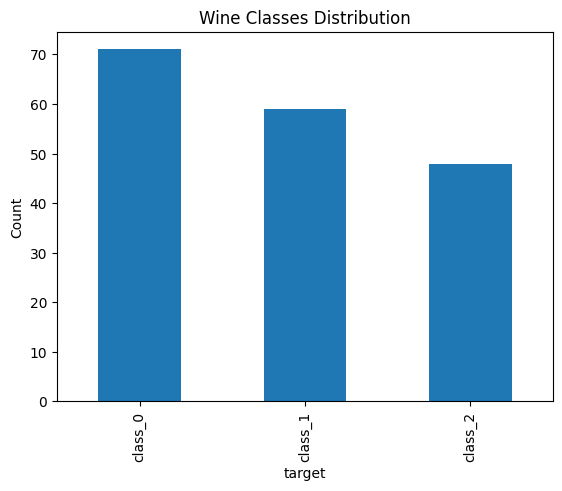

In [45]:
import matplotlib.pyplot as plt

df["target"] = data.target
df["target"].value_counts().plot(kind="bar")
plt.xticks([0,1,2], data.target_names)
plt.title("Wine Classes Distribution")
plt.ylabel("Count")
plt.show()


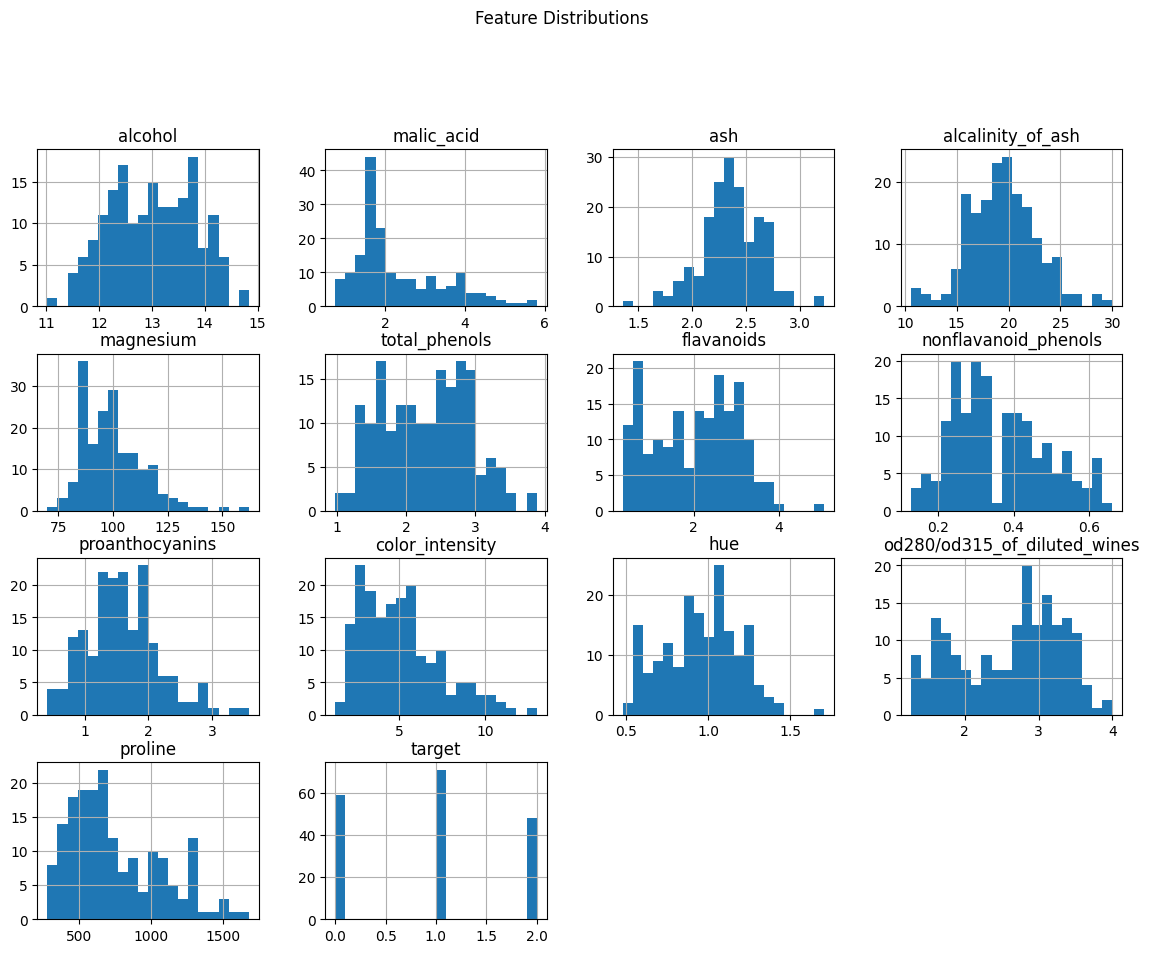

In [23]:
df.hist(figsize=(14, 10), bins=20)
plt.suptitle("Feature Distributions", y=1.02)
plt.show()


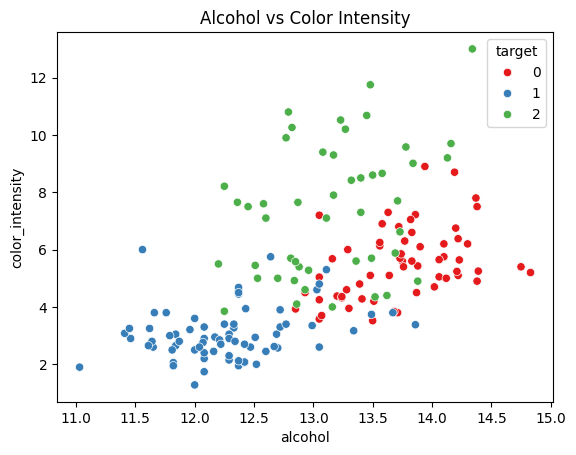

In [24]:
import seaborn as sns

sns.scatterplot(data=df, x="alcohol", y="color_intensity", hue="target", palette="Set1")
plt.title("Alcohol vs Color Intensity")
plt.show()


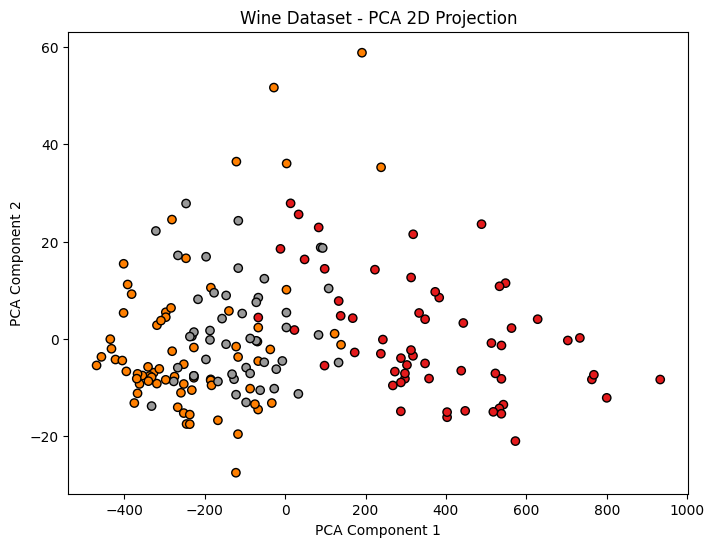

In [46]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(df[data.feature_names])

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df["target"], cmap="Set1", edgecolors="k")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Wine Dataset - PCA 2D Projection")
plt.show()


Baseline model, logistic regression

In [47]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=500))
])

pipe_lr.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', LogisticRegression(max_iter=500))])

Decision tree

In [48]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [42]:
from sklearn import tree

text_tree = tree.export_text(model, feature_names=list(subset.columns))
print(text_tree)


|--- alcohol <= 12.76
|   |--- alcohol <= 12.18
|   |   |--- class: 1
|   |--- alcohol >  12.18
|   |   |--- alcohol <= 12.27
|   |   |   |--- magnesium <= 84.50
|   |   |   |   |--- class: 1
|   |   |   |--- magnesium >  84.50
|   |   |   |   |--- magnesium <= 131.50
|   |   |   |   |   |--- class: 2
|   |   |   |   |--- magnesium >  131.50
|   |   |   |   |   |--- class: 1
|   |   |--- alcohol >  12.27
|   |   |   |--- alcohol <= 12.35
|   |   |   |   |--- class: 1
|   |   |   |--- alcohol >  12.35
|   |   |   |   |--- alcohol <= 12.36
|   |   |   |   |   |--- class: 2
|   |   |   |   |--- alcohol >  12.36
|   |   |   |   |   |--- magnesium <= 92.00
|   |   |   |   |   |   |--- magnesium <= 85.50
|   |   |   |   |   |   |   |--- magnesium <= 84.50
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |--- magnesium >  84.50
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- magnesium >  85.50
|   |   |   |   |   |   |   |--- class: 1
|   | 

In [53]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


ValueError: could not convert string to float: 'class_0'

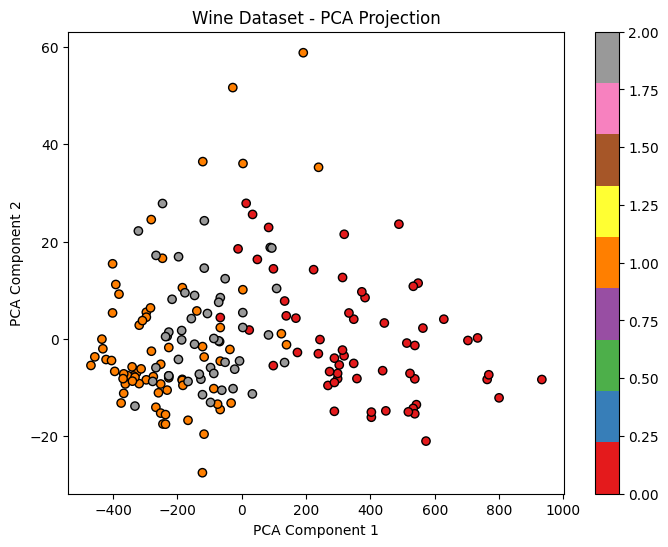

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap="Set1", edgecolors="k")

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Wine Dataset - PCA Projection")
plt.colorbar()
plt.show()


In [55]:
pca_components = pd.DataFrame(
    pca.components_,
    columns=data.feature_names,
    index=["PC1", "PC2"]
)
print(pca_components)


      alcohol  malic_acid       ash  alcalinity_of_ash  magnesium  \
PC1  0.001659   -0.000681  0.000195          -0.004671   0.017868   
PC2  0.001203    0.002155  0.004594           0.026450   0.999344   

     total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
PC1       0.000990    0.001567             -0.000123         0.000601   
PC2       0.000878   -0.000052             -0.001354         0.005004   

     color_intensity       hue  od280/od315_of_diluted_wines   proline  
PC1         0.002327  0.000171                      0.000705  0.999823  
PC2         0.015100 -0.000763                     -0.003495 -0.017774  


In [52]:
from mpl_toolkits.mplot3d import Axes3D

pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_scaled)

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca3[:,0], X_pca3[:,1], X_pca3[:,2], c=y, cmap="Set1")

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.title("Wine Dataset - 3D PCA")
plt.show()


NameError: name 'X_scaled' is not defined

Trying different model

In [28]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

models = {
    "Logistic Regression": pipe_lr,
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC())
    ]),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}


Evaluate

In [29]:
from sklearn.metrics import classification_report

y_pred = pipe_lr.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.67      0.74      0.70        19
           1       0.86      0.86      0.86        21
           2       0.42      0.36      0.38        14

    accuracy                           0.69        54
   macro avg       0.65      0.65      0.65        54
weighted avg       0.68      0.69      0.68        54



Cross validation

In [ ]:
from sklearn.model_selection import cross_val_score

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5)
    print(f"{name}: mean={scores.mean():.3f}, std={scores.std():.3f}")


In [34]:
from sklearn.decomposition import PCA

pipe_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2)),
    ("clf", LogisticRegression(max_iter=500))
])

pipe_pca.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=2)),
                ('clf', LogisticRegression(max_iter=500))])

In [ ]:
import matplotlib.pyplot as plt

X_pca = pipe_pca.named_steps["pca"].transform(
    pipe_pca.named_steps["scaler"].transform(X)
)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="viridis")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Wine Dataset - PCA Projection")
plt.show()


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- alcalinity_of_ash
- ash
- class
- color_intensity
- flavanoids
- ...


Confusion matrix

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

best_model = models["Random Forest"]
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()
